In [1]:
import findspark
findspark.init()

In [2]:
test_data_no_loc = "../Datasets/Brain_Tumor_Datasets/test/no"
test_data_yes_loc = "../Datasets/Brain_Tumor_Datasets/test/yes"
train_data_no_loc = "../Datasets/Brain_Tumor_Datasets/train/no"
train_data_yes_loc = "../Datasets/Brain_Tumor_Datasets/train/yes"


In [3]:
from PIL import Image
import numpy as np
import pandas as pd
import os

def preprocess_images_from_dir(directory, label, size=(64, 64)):
    data = []
    for fname in os.listdir(directory):
        if fname.lower().endswith(('.jpg', '.png', '.jpeg')):
            try:
                img = Image.open(os.path.join(directory, fname)).convert('L').resize(size)
                arr = np.array(img).flatten() / 255.0  # normalize
                data.append((arr.tolist(), label))
            except Exception as e:
                print(f"Failed on {fname}: {e}")
    return pd.DataFrame(data, columns=['features', 'label'])


In [4]:
test_no_df = preprocess_images_from_dir(test_data_no_loc, label=0)
test_yes_df = preprocess_images_from_dir(test_data_yes_loc, label=1)
train_no_df = preprocess_images_from_dir(train_data_no_loc, label=0)
train_yes_df = preprocess_images_from_dir(train_data_yes_loc, label=1)

In [5]:
full_df = pd.concat([test_no_df, test_yes_df, train_no_df, train_yes_df], ignore_index=True)

In [6]:
print(full_df['label'].value_counts())


label
1    5178
0    3586
Name: count, dtype: int64


<ipython-input-7-8b5a3a7712a6>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = full_df, x = 'label', palette = 'coolwarm')


<Axes: xlabel='label', ylabel='count'>

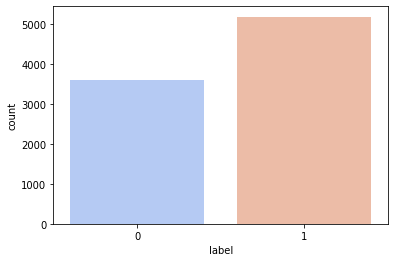

In [7]:
import seaborn as sns
sns.countplot(data = full_df, x = 'label', palette = 'coolwarm')

In [8]:
full_df.head()

,features,label
0,"[0.0, 0.0, 0.0, 0.0, 0.00784313725490196, 0.00...",0
1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0
2,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0
3,"[0.00392156862745098, 0.00392156862745098, 0.0...",0
4,"[0.10980392156862745, 0.10980392156862745, 0.1...",0


In [9]:
from pyspark.sql import SparkSession, Row


In [10]:
spark = SparkSession.builder.appName("image_pipeline").getOrCreate()

rows = [Row(features=row['features'], label=int(row['label'])) for _, row in full_df.iterrows()]
spark_df = spark.createDataFrame(rows)

spark_df.printSchema()
spark_df.show(5)

root
 |-- features: array (nullable = true)
 |    |-- element: double (containsNull = true)
 |-- label: long (nullable = true)

+--------------------+-----+
|            features|label|
+--------------------+-----+
|[0.0, 0.0, 0.0, 0...|    0|
|[0.0, 0.0, 0.0, 0...|    0|
|[0.0, 0.0, 0.0, 0...|    0|
|[0.00392156862745...|    0|
|[0.10980392156862...|    0|
+--------------------+-----+
only showing top 5 rows

